In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression

In [2]:
dataset = pd.read_csv('../../data/train.csv')

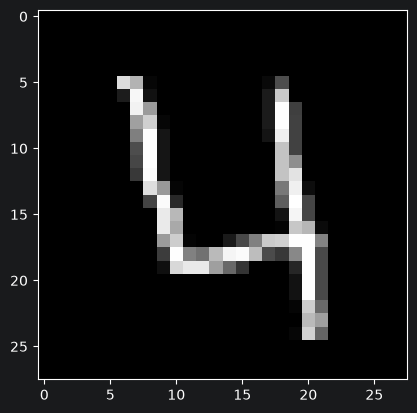

In [11]:
# 测试图像
digit = dataset.iloc[3,1:].values
plt.imshow(digit.reshape(28, 28), cmap='gray')
plt.show()

In [13]:
print(len(dataset))
dataset.head()

42000


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
# 划分数据集
X = dataset.drop(columns='label')
y = dataset['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(33600, 784) (8400, 784) (33600,) (8400,)


In [15]:
# 3. 特征工程
# 归一化
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. 定义模型和训练
# model = LogisticRegression() # Increase the number of iterations to improve the convergence (max_iter=100).
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 5. 模型评估
score = model.score(X_test, y_test)
print(score)

0.9186904761904762


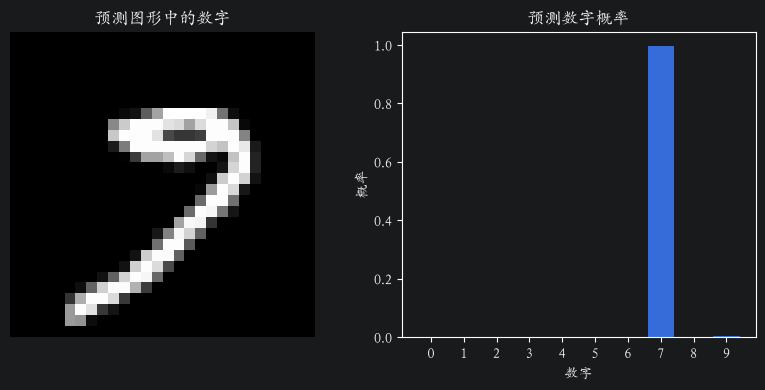

预测：[7], 实际：9


In [25]:
# 6. 测试
test_case = 77
digit = X_test[test_case, :].reshape(1, -1)

plt.rcParams['font.sans-serif'] = ['Kai']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(digit.reshape(28, 28), cmap='gray')
plt.title('预测图形中的数字')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.bar(np.arange(10), model.predict_proba(digit).flatten())
plt.xlabel('数字')
plt.ylabel('概率')
plt.title('预测数字概率')
plt.xticks(np.arange(10))

plt.tight_layout()
plt.show()

print(f'预测：{model.predict(digit)}, 实际：{y_test.iloc[test_case]}')
# print(model.predict_proba(digit))